<a href="https://colab.research.google.com/github/lukazsw/Machine-Learning-2025L/blob/main/lw430257_homework01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praca Domowa: LAB01_PCA
# Autor: Łukasz Wysocki

Celem zadania jest zastosowanie analizy głównych składowych (PCA) do danych 3-wymiarowych zawierających trzy klasy<br>(`class = 0, 1, 2`) oraz porównanie rzutu PCA z wykresami w oryginalnych przestrzeniach cech:

- `x` vs `y`
- `x` vs `z`
- `y` vs `z`

Przed wykonaniem PCA dane zostały wystandaryzowane, tak aby każda cecha miała średnią równą `0` oraz wariancję równą `1`.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [19]:
url = "https://raw.githubusercontent.com/SzymonNowakowski/Machine-Learning-2025L/master/PCA_three_clusters_data.csv"
df = pd.read_csv(url)

In [20]:
print("Shape:", df.shape)
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nClass counts:")
print(df["class"].value_counts().sort_index())

Shape: (300, 4)
          x         y          z  class
0  0.647689 -0.138264   3.512299      0
1 -0.234137 -0.234153  10.769447      0
2 -0.469474  0.767435  11.166721      0
3 -0.465730 -0.463418   3.836479      0
4 -1.724918 -1.913280   1.710932      0

Columns: ['x', 'y', 'z', 'class']

Class counts:
class
0    100
1    100
2    100
Name: count, dtype: int64


In [22]:
X = df[["x", "y", "z"]]
y = df["class"]

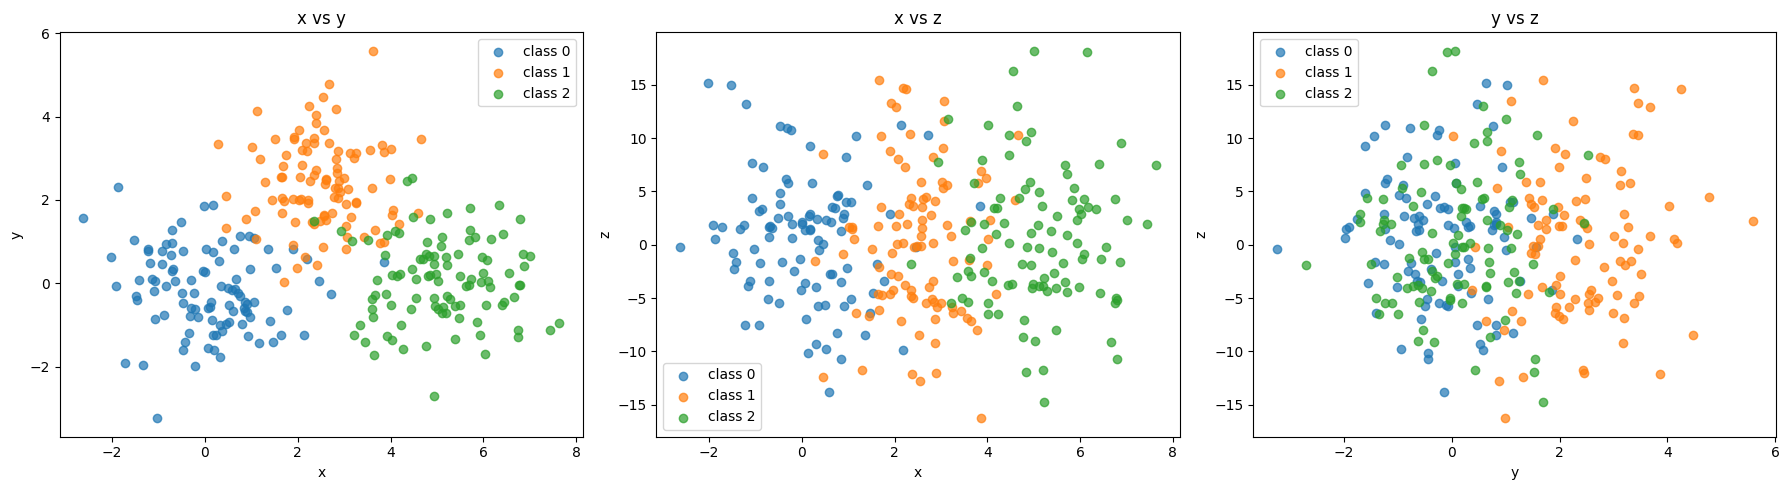

In [23]:
feature_pairs = [("x", "y"), ("x", "z"), ("y", "z")]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (f1, f2) in zip(axes, feature_pairs):
    for cls in sorted(y.unique()):
        mask = y == cls
        ax.scatter(
            df.loc[mask, f1],
            df.loc[mask, f2],
            label=f"class {cls}",
            alpha=0.7
        )
    ax.set_xlabel(f1)
    ax.set_ylabel(f2)
    ax.set_title(f"{f1} vs {f2}")
    ax.legend()

plt.tight_layout()
plt.show()

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Means after standardization:", X_scaled.mean(axis=0))
print("Std after standardization:", X_scaled.std(axis=0))

Means after standardization: [0.00000000e+00 4.73695157e-17 5.92118946e-18]
Std after standardization: [1. 1. 1.]


In [27]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [28]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["class"] = y.values

In [29]:
print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)


Explained variance ratio:
[0.34722276 0.33441835]


In [30]:
print("\nCumulative explained variance (2 PCs):")
print(pca.explained_variance_ratio_.sum())


Cumulative explained variance (2 PCs):
0.6816411077913826


In [31]:
print("\nPrincipal component directions (loadings):")
loadings = pd.DataFrame(
    pca.components_,
    columns=["x", "y", "z"],
    index=["PC1", "PC2"]
)
print(loadings)


Principal component directions (loadings):
            x         y         z
PC1  0.720058  0.569460 -0.396525
PC2 -0.023683  0.591267  0.806128


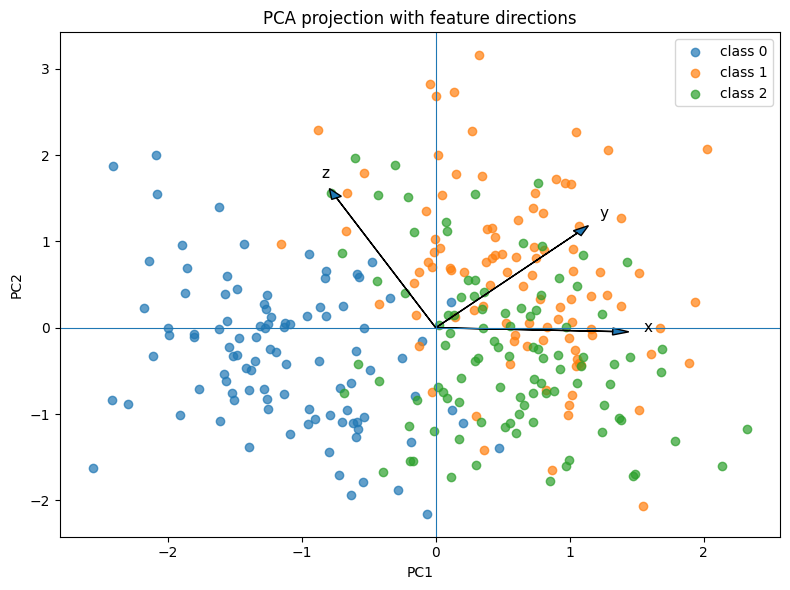

In [32]:
plt.figure(figsize=(8, 6))

for cls in sorted(y.unique()):
    mask = y == cls
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"class {cls}",
        alpha=0.7
    )

feature_names = ["x", "y", "z"]
for i, feature in enumerate(feature_names):
    plt.arrow(
        0, 0,
        pca.components_[0, i] * 2,
        pca.components_[1, i] * 2,
        head_width=0.08,
        length_includes_head=True
    )
    plt.text(
        pca.components_[0, i] * 2.15,
        pca.components_[1, i] * 2.15,
        feature,
        fontsize=11
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection with feature directions")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

Po standaryzacji danych zastosowano PCA i zredukowano wymiar z 3 do 2, otrzymując dwie pierwsze główne składowe: `PC1` oraz `PC2`.

### Wyniki PCA

Dwie pierwsze składowe główne wyjaśniają następującą część wariancji:

- **PC1:** 34.72%
- **PC2:** 33.44%

Łącznie daje to:

- **68.16% całkowitej wariancji danych**

Oznacza to, że rzut danych na dwie pierwsze składowe zachowuje znaczną część informacji zawartej w oryginalnej przestrzeni 3D, chociaż nie całość.

### Porównanie PCA z wykresami w oryginalnych przestrzeniach cech

Porównując wykres PCA z wykresami `x` vs `y`, `x` vs `z` oraz `y` vs `z`, można zauważyć, że:

- wykres **`x` vs `y`** już bardzo dobrze pokazuje strukturę trzech klastrów,
- wykresy **`x` vs `z`** oraz **`y` vs `z`** pokazują większe nakładanie się punktów różnych klas,
- wykres **PCA** daje sensowny 2D rzut danych, ale **nie poprawia wyraźnie separacji wszystkich klas względem najlepszego oryginalnego wykresu**, czyli `x` vs `y`.

Na wykresie PCA:
- **class 0** pozostaje dość dobrze oddzielona od reszty,
- natomiast **class 1** i **class 2** nakładają się bardziej niż na wykresie `x` vs `y`.

### Czy PCA poprawia separację klastrów?

**Nie w sposób jednoznaczny.**  
W tym zbiorze danych PCA nie daje wyraźnie lepszej separacji niż najlepsza para oryginalnych cech.

### Dlaczego tak się dzieje?

PCA szuka takich kierunków w danych, które maksymalizują wariancję, a nie takich, które najlepiej rozdzielają klasy. Jest to metoda **nienadzorowana**, czyli nie korzysta z informacji o etykietach klas podczas wyznaczania nowych osi.

To oznacza, że:
- PCA może bardzo dobrze kompresować dane,
- może dawać czytelny rzut do wizualizacji,
- ale nie musi prowadzić do najlepszego rozdzielenia klas.

W tym przypadku największa wariancja danych nie pokrywa się idealnie z kierunkami najlepszego rozdziału między wszystkimi trzema klastrami.

### Dlaczego standaryzacja przed PCA jest konieczna?

Standaryzacja jest bardzo ważna przed zastosowaniem PCA, ponieważ PCA opiera się na wariancji cech. Jeśli jedna zmienna ma większą skalę liczbową albo większą wariancję niż pozostałe, to będzie miała nieproporcjonalnie duży wpływ na kierunki głównych składowych.

Po standaryzacji każda cecha:
- ma średnią równą `0`,
- ma wariancję równą `1`.

Dzięki temu wszystkie zmienne są traktowane w sposób porównywalny.

### Jak różnice skali wpływają na kierunki głównych składowych?

Jeżeli cechy mają różne skale, to PCA będzie preferować te cechy, które mają największe wartości lub największy rozrzut. W efekcie:

- kierunki składowych głównych mogą zostać zdominowane przez jedną zmienną,
- wynik PCA może bardziej odzwierciedlać różnice jednostek i skali niż rzeczywistą strukturę danych,
- wizualizacja i interpretacja mogą być mylące.

Standaryzacja pozwala uniknąć tego problemu i sprawia, że PCA analizuje relacje między cechami, a nie tylko ich zakresy wartości.

Współczynniki składowych głównych (loadings) mają postać:

| Component | x        | y        | z         |
|-----------|----------|----------|-----------|
| PC1       | 0.720058 | 0.569460 | -0.396525 |
| PC2       | -0.023683 | 0.591267 | 0.806128 |

### Interpretacja

**PC1** jest silnie związana z cechami `x` i `y` (dodatnio), a jednocześnie ujemnie z `z`.  
Można więc powiedzieć, że pierwsza składowa opisuje kierunek, w którym jednocześnie rosną `x` i `y`, a `z` maleje.

**PC2** jest silnie związana z `y` i `z`, natomiast wpływ `x` jest bardzo mały.  
Oznacza to, że druga składowa reprezentuje głównie wspólną zmienność cech `y` oraz `z`.

To potwierdza, że PCA tworzy nowe osie jako kombinacje liniowe oryginalnych zmiennych, a nie wybiera po prostu jednej z istniejących cech.

PCA pozwoliło zredukować dane 3D do 2D przy zachowaniu około **68.16% wariancji**, co daje użyteczną i czytelną wizualizację danych.

Jednak w tym konkretnym przypadku PCA **nie poprawiło wyraźnie separacji klastrów** względem najlepszego wykresu w oryginalnej przestrzeni cech, czyli `x` vs `y`.

Najważniejszy wniosek jest taki, że PCA jest bardzo przydatne do:
- redukcji wymiaru,
- wizualizacji danych,
- kompresji informacji,

ale nie jest metodą zaprojektowaną specjalnie do separacji klas.  
Maksymalizacja wariancji nie musi oznaczać maksymalizacji rozdzielności między grupami.

## Dodatkowe wnioski - wykres 3D


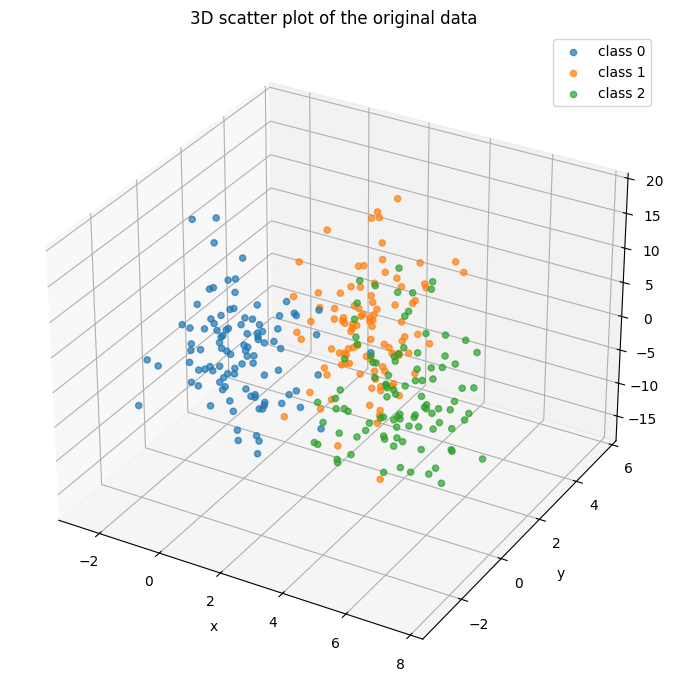

In [36]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for cls in sorted(df["class"].unique()):
    mask = df["class"] == cls
    ax.scatter(
        df.loc[mask, "x"],
        df.loc[mask, "y"],
        df.loc[mask, "z"],
        label=f"class {cls}",
        alpha=0.7
    )

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("3D scatter plot of the original data")
ax.legend()

plt.tight_layout()
plt.show()

Dodatkowy wykres 3D pokazuje pełną strukturę danych w oryginalnej przestrzeni `x-y-z`.  
Taka wizualizacja pomaga zrozumieć, jak wygląda rozmieszczenie klastrów przed redukcją wymiaru oraz ile informacji może zostać utracone przy przejściu z 3D do 2D.

Widać, że część separacji między klasami jest dobrze widoczna już w oryginalnej przestrzeni, ale po redukcji do dwóch wymiarów pewne obszary zaczynają się bardziej nakładać.

## Dodatkowe wnioski - brak standaryzacji

Dla porównania wykonano również PCA **bez wcześniejszej standaryzacji cech**.

Explained variance ratio without standardization:
[0.83996129 0.11106345]

Cumulative explained variance without standardization:
0.9510247370562541

Principal component directions without standardization:
            x         y         z
PC1 -0.010740  0.000841  0.999942
PC2  0.999078  0.041570  0.010696


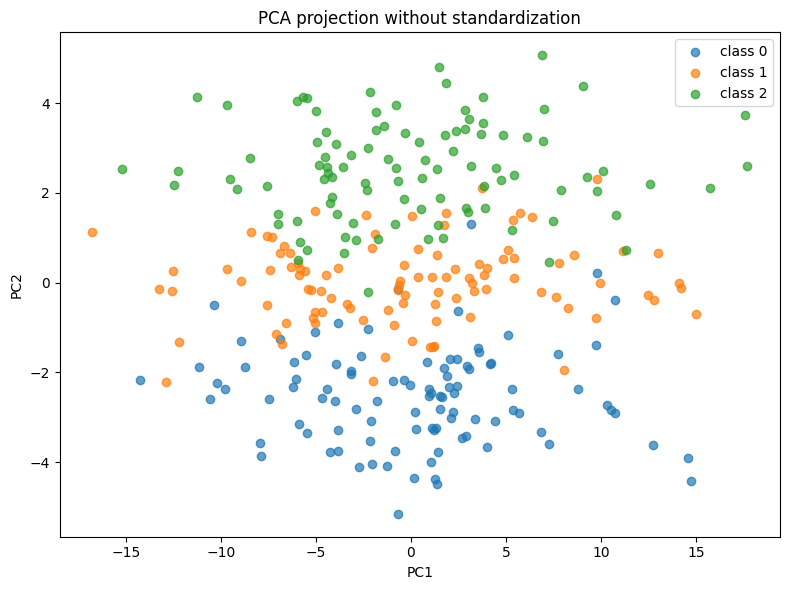

In [35]:
pca_no_scaling = PCA(n_components=2)
X_pca_no_scaling = pca_no_scaling.fit_transform(X)

print("Explained variance ratio without standardization:")
print(pca_no_scaling.explained_variance_ratio_)

print("\nCumulative explained variance without standardization:")
print(pca_no_scaling.explained_variance_ratio_.sum())

loadings_no_scaling = pd.DataFrame(
    pca_no_scaling.components_,
    columns=["x", "y", "z"],
    index=["PC1", "PC2"]
)

print("\nPrincipal component directions without standardization:")
print(loadings_no_scaling)

plt.figure(figsize=(8, 6))

for cls in sorted(y.unique()):
    mask = y == cls
    plt.scatter(
        X_pca_no_scaling[mask, 0],
        X_pca_no_scaling[mask, 1],
        label=f"class {cls}",
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection without standardization")
plt.legend()
plt.tight_layout()
plt.show()

### Wyniki

W tym przypadku dwie pierwsze składowe główne wyjaśniają:

- **PC1:** 83.996%
- **PC2:** 11.106%

Łącznie:

- **95.10% wariancji**

Na pierwszy rzut oka może to wyglądać bardzo dobrze, ponieważ dwie składowe zachowują prawie całą informację o zmienności danych. Taki wynik jest jednak mylący, ponieważ bez standaryzacji PCA zostało silnie zdominowane przez jedną zmienną.

### Interpretacja kierunków składowych

Macierz współczynników ma postać:

| Component | x         | y         | z         |
|-----------|-----------|-----------|-----------|
| PC1       | -0.010740 | 0.000841  | 0.999942  |
| PC2       | 0.999078  | 0.041570  | 0.010696  |

Widać bardzo wyraźnie, że:

- **PC1** jest praktycznie tożsama ze zmienną `z`,
- **PC2** jest prawie tożsama ze zmienną `x`,
- zmienna `y` ma bardzo mały wpływ na obie pierwsze składowe.

To oznacza, że PCA bez standaryzacji nie znajduje zrównoważonych kombinacji wszystkich cech, lecz przede wszystkim odtwarza osie związane ze zmiennymi o największej wariancji.

### Wniosek

Brak standaryzacji sprawia, że PCA jest zdominowane przez cechy o większym rozrzucie wartości. W tym zbiorze danych szczególnie silny wpływ ma zmienna `z`, która niemal w całości wyznacza pierwszą składową główną.

Dlatego mimo że łączny udział wyjaśnionej wariancji bez standaryzacji jest bardzo wysoki (**95.10%**), taki wynik nie musi prowadzić do lepszej interpretacji struktury danych ani do bardziej sprawiedliwego uwzględnienia wszystkich cech.

Porównanie PCA ze standaryzacją i bez standaryzacji pokazuje więc, że **wysoki explained variance ratio sam w sobie nie oznacza jeszcze lepszego PCA**. Właśnie dlatego standaryzacja jest standardowym i bardzo ważnym krokiem przed zastosowaniem tej metody.